In [22]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df=pd.read_csv("Titanic-Dataset.csv")

In [24]:
df=df[["Age","Fare","SibSp","Survived"]]

In [25]:
df.head()

,Age,Fare,SibSp,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      891 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [27]:
df.isnull().mean()*100

Age         19.86532
Fare         0.00000
SibSp        0.00000
Survived     0.00000
dtype: float64

<Axes: >

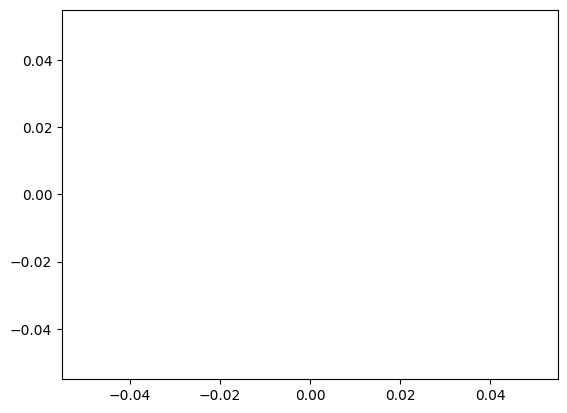

In [28]:
sns.histplot()

In [29]:
X=df.drop(columns=["Survived"],axis=1)
y=df["Survived"]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [32]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [33]:
mean_age=df["Age"].mean()
median_age=df["Age"].median()

In [34]:
X_train["mean_age"]=df["Age"].fillna(mean_age)
X_train["median_age"]=df["Age"].fillna(median_age)

In [35]:
X_train.sample(5)

,Age,Fare,SibSp,mean_age,median_age
574,16.0,8.0500,0,16.0,16.0
586,47.0,15.0000,0,47.0,47.0
114,17.0,14.4583,0,17.0,17.0
561,40.0,7.8958,0,40.0,40.0
526,50.0,10.5000,0,50.0,50.0


In [36]:
print("Origional age Varience",X_train["Age"].var())
print("Origional median_age Varience",X_train["median_age"].var())
print("Origional mean_age Varience",X_train["mean_age"].var())

Origional age Varience 204.34951339046142
Origional median_age Varience 162.3385298533084
Origional mean_age Varience 161.81386645586778


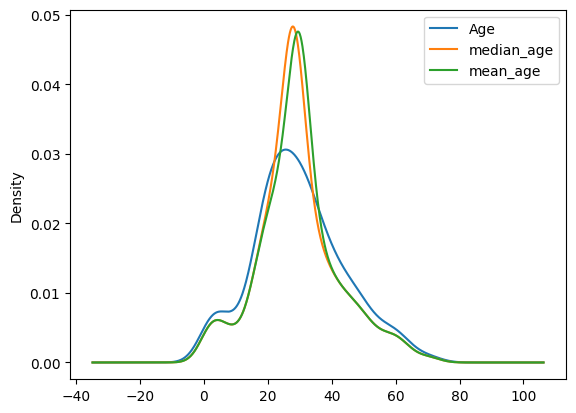

In [37]:
fig=plt.figure()
ax=fig.add_subplot(111)
X_train["Age"].plot(kind="kde",ax=ax)
X_train["median_age"].plot(kind="kde",ax=ax)
X_train["mean_age"].plot(kind="kde",ax=ax)
ax.legend()

In [38]:
X_train.cov()

,Age,Fare,SibSp,mean_age,median_age
Age,204.349513,71.512440,-4.165283,204.349513,204.349513
Fare,71.512440,2368.246832,8.567003,56.824300,60.695143
SibSp,-4.165283,8.567003,1.267996,-3.299378,-3.321504
mean_age,204.349513,56.824300,-3.299378,161.813866,161.838181
median_age,204.349513,60.695143,-3.321504,161.838181,162.338530


In [39]:
X_train.corr()

,Age,Fare,SibSp,mean_age,median_age
Age,1.000000,0.095814,-0.309514,1.000000,1.000000
Fare,0.095814,1.000000,0.156335,0.091794,0.097888
SibSp,-0.309514,0.156335,1.000000,-0.230338,-0.231507
mean_age,1.000000,0.091794,-0.230338,1.000000,0.998533
median_age,1.000000,0.097888,-0.231507,0.998533,1.000000


<Axes: >

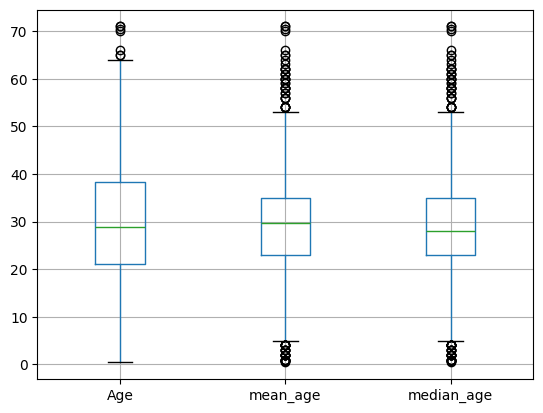

In [40]:
X_train[["Age","mean_age","median_age"]].boxplot()

In [41]:
df["Age"].isnull().value_counts()

Age
False    714
True     177
Name: count, dtype: int64

In [54]:
X_train["Age99"]=df["Age"].fillna(99)
X_train["Age99"].isnull().value_counts()

Age99
False    712
Name: count, dtype: int64

In [55]:
X_train["Age-1"]=df["Age"].fillna(-1)
X_train["Age-1"].isnull().value_counts()

Age-1
False    712
Name: count, dtype: int64

In [59]:
print("Origional age varience variable",X_train["Age"].var())
print("age99 after imputation",X_train["Age99"].var())
print("age-1 after imputation",X_train["Age-1"].var())

Origional age varience variable 204.34951339046142
age99 after imputation 951.7275570187188
age-1 after imputation 318.0896202624488


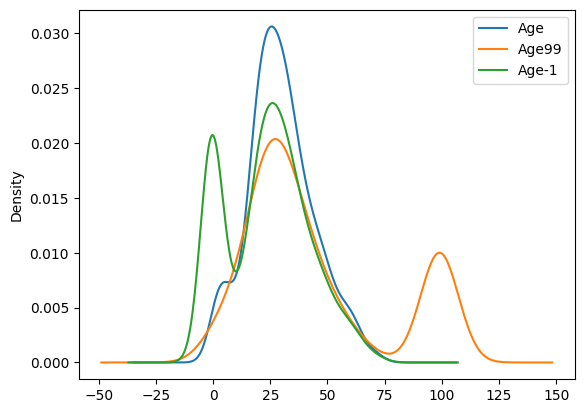

In [69]:
ax=plt.figure().add_subplot()
X_train["Age"].plot(kind="kde",ax=ax)
X_train["Age99"].plot(kind="kde",ax=ax)
X_train["Age-1"].plot(kind="kde",ax=ax)
ax.legend()

In [72]:
X_train,X_train,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [83]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
imputer1=SimpleImputer(strategy="constant",fill_value=99)
imputer2=SimpleImputer(strategy="constant",fill_value=999)
trf=ColumnTransformer([
    ("imputer1",imputer1,["Age"]),
    ("imputer2",imputer2,["Age"])
],remainder="passthrough")

In [84]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [85]:
df['Age'].isnull().sum()


np.int64(177)